# Real Data Barcode Calling Comparison

This notebook compares the performance of three barcode calling tools (RandomBarcodes, QUIK, Columba) on real Munich sequencing data.

## Methodology
- **Real barcodes**: Tools called barcodes from actual barcode library
- **Decoy barcodes**: Tools attempted to call non-existent barcodes (false positives)
- **Precision**: Calculated as 100% - (% reads assigned to decoy barcodes)

## Datasets
- **21k**: 21,476 barcodes (Munchen_25024_1in4)
- **42k**: 42,653 barcodes (Munchen_25024_1in2)
- **85k**: 85,305 barcodes (Munchen_25024_1in1)

All barcodes are 36nt long, positioned at bases 10-45 (after 10nt UMI).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 1. Parse Statistics Files

In [2]:
def parse_randombarcodes_stats(filepath):
    """Parse RandomBarcodes stats file."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract R1 reads count
    r1_match = re.search(r'R1 reads:\s+(\d+)', content)
    assigned = int(r1_match.group(1)) if r1_match else 0
    
    return assigned

def parse_quik_stats(filepath):
    """Parse QUIK stats file."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract total and assigned reads
    total_match = re.search(r'Total reads:\s+(\d+)', content)
    assigned_match = re.search(r'Assigned reads:\s+(\d+)', content)
    
    total = int(total_match.group(1)) if total_match else 0
    assigned = int(assigned_match.group(1)) if assigned_match else 0
    
    return total, assigned

def parse_columba_stats(filepath):
    """Parse Columba stats file."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract total and mapped reads
    total_match = re.search(r'Total reads:\s+(\d+)', content)
    mapped_match = re.search(r'Mapped reads:\s+(\d+)', content)
    
    total = int(total_match.group(1)) if total_match else 0
    mapped = int(mapped_match.group(1)) if mapped_match else 0
    
    return total, mapped

In [4]:
# Define base results directory - updated to match generation script output directory
results_dir = Path('../results/real_data')

# Define datasets
datasets = ['21k', '42k', '85k']
tools = ['RandomBarcodes', 'QUIK', 'Columba']

# Initialize results dictionary
results = []

# Parse RandomBarcodes results
for dataset in datasets:
    # Real data
    real_file = results_dir / f'randombarcodes/{dataset}/RB_real_{dataset}/RB_real_{dataset}_barcode_calling_stats.txt'
    real_assigned = parse_randombarcodes_stats(real_file)
    
    # Decoy data
    decoy_file = results_dir / f'randombarcodes/{dataset}_decoy/RB_decoy_{dataset}/RB_decoy_{dataset}_barcode_calling_stats.txt'
    decoy_assigned = parse_randombarcodes_stats(decoy_file)
    
    # For RandomBarcodes, we need to get total reads from QUIK (since RB only reports assigned)
    quik_file = results_dir / f'quik/{dataset}/QUIK_real_{dataset}/QUIK_real_{dataset}_barcode_calling_stats.txt'
    total_reads, _ = parse_quik_stats(quik_file)
    
    # Calculate precision
    false_positive_rate = (decoy_assigned / total_reads) * 100 if total_reads > 0 else 0
    precision = 100 - false_positive_rate
    
    results.append({
        'Tool': 'RandomBarcodes',
        'Dataset': dataset,
        'Total_Reads': total_reads,
        'Assigned_Reads': real_assigned,
        'Decoy_Assigned': decoy_assigned,
        'Assignment_Rate': (real_assigned / total_reads * 100) if total_reads > 0 else 0,
        'False_Positive_Rate': false_positive_rate,
        'Precision': precision
    })

# Parse QUIK results
for dataset in datasets:
    # Real data
    real_file = results_dir / f'quik/{dataset}/QUIK_real_{dataset}/QUIK_real_{dataset}_barcode_calling_stats.txt'
    total_reads, real_assigned = parse_quik_stats(real_file)
    
    # Decoy data
    decoy_file = results_dir / f'quik/{dataset}_decoy/QUIK_decoy_{dataset}/QUIK_decoy_{dataset}_barcode_calling_stats.txt'
    _, decoy_assigned = parse_quik_stats(decoy_file)
    
    # Calculate precision
    false_positive_rate = (decoy_assigned / total_reads) * 100 if total_reads > 0 else 0
    precision = 100 - false_positive_rate
    
    results.append({
        'Tool': 'QUIK',
        'Dataset': dataset,
        'Total_Reads': total_reads,
        'Assigned_Reads': real_assigned,
        'Decoy_Assigned': decoy_assigned,
        'Assignment_Rate': (real_assigned / total_reads * 100) if total_reads > 0 else 0,
        'False_Positive_Rate': false_positive_rate,
        'Precision': precision
    })

# Parse Columba results (I77 only)
for dataset in datasets:
    # Real data
    if dataset == '21k':
        real_file = results_dir / f'columba/{dataset}_I77/Columba_real_{dataset}_I77/Columba_real_{dataset}_I77_barcode_calling_stats.txt'
    else:
        real_file = results_dir / f'columba/{dataset}_I80/Columba_real_{dataset}_I80/Columba_real_{dataset}_I80_barcode_calling_stats.txt'
    total_reads, real_mapped = parse_columba_stats(real_file)
    
    # Decoy data
    if dataset == '21k':
        decoy_file = results_dir / f'columba/{dataset}_decoy_I77/Columba_decoy_{dataset}_I77/Columba_decoy_{dataset}_I77_barcode_calling_stats.txt'
    else:
        decoy_file = results_dir / f'columba/{dataset}_decoy_I80/Columba_decoy_{dataset}_I80/Columba_decoy_{dataset}_I80_barcode_calling_stats.txt'
    _, decoy_mapped = parse_columba_stats(decoy_file)
    
    # Calculate precision
    false_positive_rate = (decoy_mapped / total_reads) * 100 if total_reads > 0 else 0
    precision = 100 - false_positive_rate
    
    results.append({
        'Tool': 'Columba',
        'Dataset': dataset,
        'Total_Reads': total_reads,
        'Assigned_Reads': real_mapped,
        'Decoy_Assigned': decoy_mapped,
        'Assignment_Rate': (real_mapped / total_reads * 100) if total_reads > 0 else 0,
        'False_Positive_Rate': false_positive_rate,
        'Precision': precision
    })

# Create DataFrame
df = pd.DataFrame(results)
df

,Tool,Dataset,Total_Reads,Assigned_Reads,Decoy_Assigned,Assignment_Rate,False_Positive_Rate,Precision
0,RandomBarcodes,21k,657529,397108,542,60.393990,0.082430,99.917570
1,RandomBarcodes,42k,526931,263985,933,50.098590,0.177063,99.822937
2,RandomBarcodes,85k,420338,26174,2260,6.226894,0.537663,99.462337
3,QUIK,21k,657529,450460,0,68.508005,0.000000,100.000000
4,QUIK,42k,526931,301062,0,57.134995,0.000000,100.000000
5,QUIK,85k,420338,79381,68,18.885040,0.016177,99.983823
6,Columba,21k,658187,413121,1356,62.766509,0.206020,99.793980
7,Columba,42k,527259,274148,142,51.994940,0.026932,99.973068
8,Columba,85k,420637,59812,633,14.219386,0.150486,99.849514


## 2. Summary Table

In [5]:
# Create a formatted summary table
summary = df.copy()
summary['Assignment_Rate'] = summary['Assignment_Rate'].round(2).astype(str) + '%'
summary['False_Positive_Rate'] = summary['False_Positive_Rate'].round(3).astype(str) + '%'
summary['Precision'] = summary['Precision'].round(3).astype(str) + '%'

print("\n=== Barcode Calling Performance Summary ===")
print(summary.to_string(index=False))


=== Barcode Calling Performance Summary ===
          Tool Dataset  Total_Reads  Assigned_Reads  Decoy_Assigned Assignment_Rate False_Positive_Rate Precision
RandomBarcodes     21k       657529          397108             542          60.39%              0.082%   99.918%
RandomBarcodes     42k       526931          263985             933           50.1%              0.177%   99.823%
RandomBarcodes     85k       420338           26174            2260           6.23%              0.538%   99.462%
          QUIK     21k       657529          450460               0          68.51%                0.0%    100.0%
          QUIK     42k       526931          301062               0          57.13%                0.0%    100.0%
          QUIK     85k       420338           79381              68          18.89%              0.016%   99.984%
       Columba     21k       658187          413121            1356          62.77%              0.206%   99.794%
       Columba     42k       527259        

## 3. Visualizations

### 3.1 Assignment Rates with Precision Labels

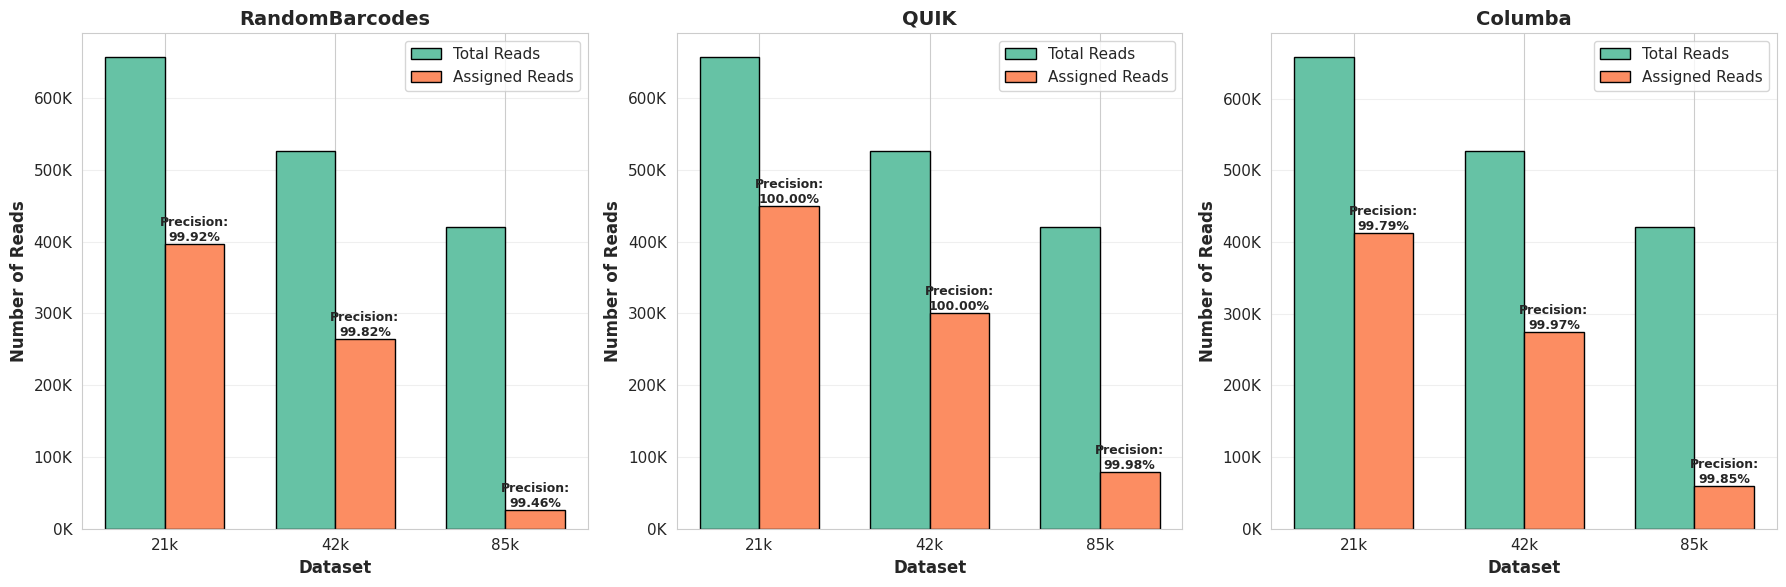


Figure saved: figures/real_data_assignment_with_precision.pdf


In [7]:
# Create grouped bar plot
palette = sns.color_palette("Set2", n_colors=10)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, tool in enumerate(tools):
    ax = axes[idx]
    tool_data = df[df['Tool'] == tool].copy()
    tool_data = tool_data.sort_values('Dataset')
    
    x = np.arange(len(datasets))
    width = 0.35
    
    # Plot total and assigned reads
    bars1 = ax.bar(x - width/2, tool_data['Total_Reads'], width, label='Total Reads', color=palette[0], edgecolor='black')
    bars2 = ax.bar(x + width/2, tool_data['Assigned_Reads'], width, label='Assigned Reads', color=palette[1], edgecolor='black')
    
    # Add precision labels on top of assigned bars
    for i, (bar, precision) in enumerate(zip(bars2, tool_data['Precision'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'Precision:\n{precision:.2f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Reads', fontsize=12, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    
    # Format y-axis to show thousands
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig('../notebooks/figures/real_data_assignment_with_precision.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/real_data_assignment_with_precision.pdf")

### 3.2 Assignment Rate Comparison

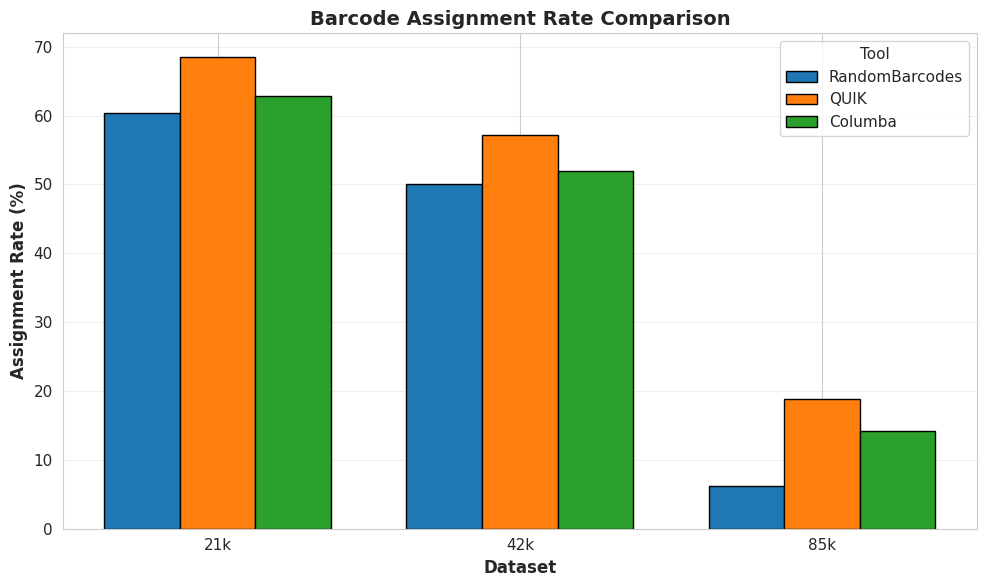


Figure saved: figures/real_data_assignment_rates.png


In [ ]:
# Grouped bar plot for assignment rates
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(datasets))
width = 0.25

for idx, tool in enumerate(tools):
    tool_data = df[df['Tool'] == tool].sort_values('Dataset')
    offset = (idx - 1) * width
    ax.bar(x + offset, tool_data['Assignment_Rate'], width, label=tool, edgecolor='black')

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Assignment Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Barcode Assignment Rate Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(title='Tool', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/real_data_assignment_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/real_data_assignment_rates.png")

### 3.3 Precision Comparison

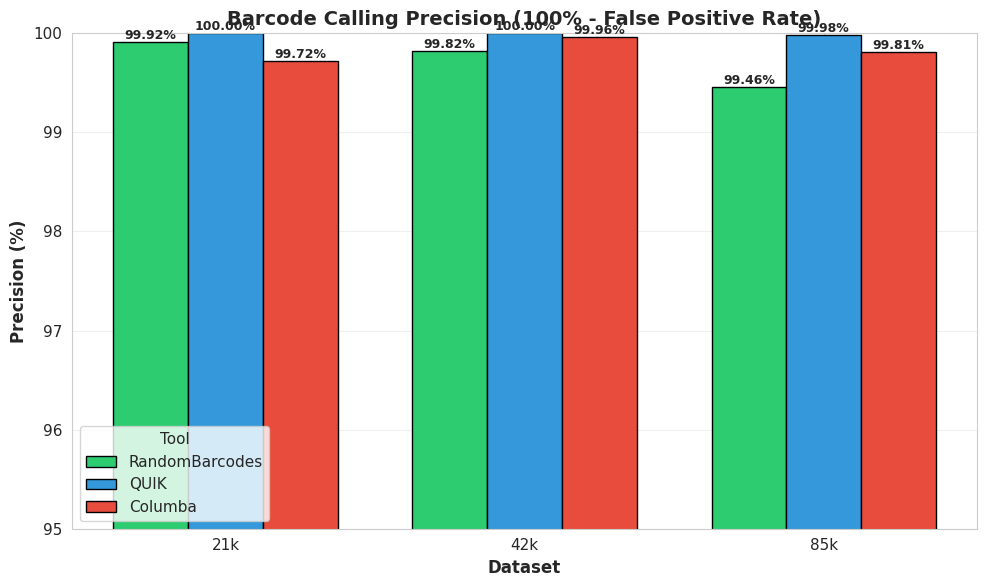


Figure saved: figures/real_data_precision.png


In [ ]:
# Grouped bar plot for precision
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(datasets))
width = 0.25

colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red

for idx, tool in enumerate(tools):
    tool_data = df[df['Tool'] == tool].sort_values('Dataset')
    offset = (idx - 1) * width
    bars = ax.bar(x + offset, tool_data['Precision'], width, label=tool, color=colors[idx], edgecolor='black')
    
    # Add value labels on bars
    for bar, precision in zip(bars, tool_data['Precision']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{precision:.2f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (%)', fontsize=12, fontweight='bold')
ax.set_title('Barcode Calling Precision (100% - False Positive Rate)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim([95, 100])  # Focus on high precision range
ax.legend(title='Tool', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/real_data_precision.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/real_data_precision.png")

### 3.4 False Positive Rates (Decoy Assignment)

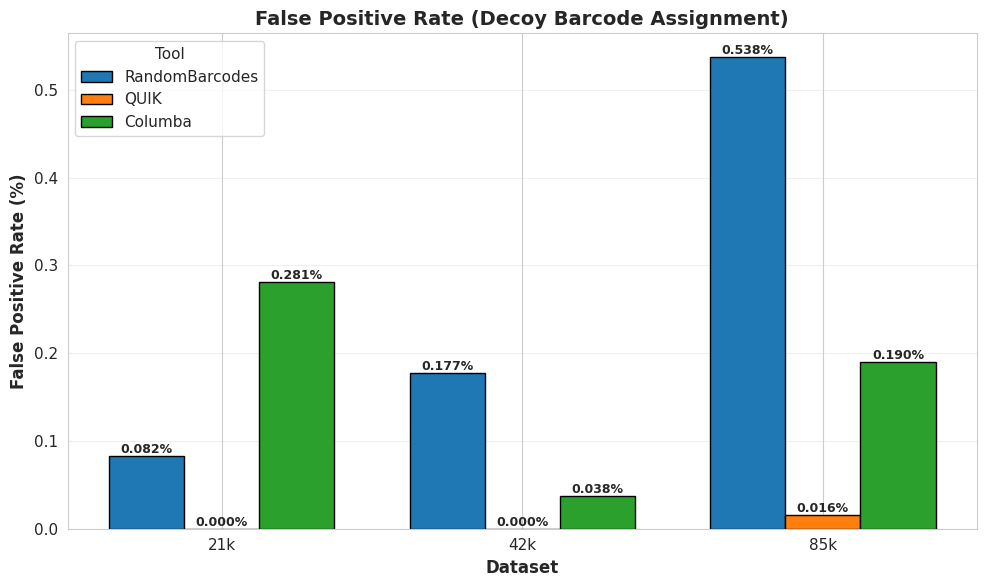


Figure saved: figures/real_data_false_positives.png


In [ ]:
# Bar plot for false positive rates
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(datasets))
width = 0.25

for idx, tool in enumerate(tools):
    tool_data = df[df['Tool'] == tool].sort_values('Dataset')
    offset = (idx - 1) * width
    bars = ax.bar(x + offset, tool_data['False_Positive_Rate'], width, label=tool, edgecolor='black')
    
    # Add value labels
    for bar, fpr in zip(bars, tool_data['False_Positive_Rate']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{fpr:.3f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('False Positive Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('False Positive Rate (Decoy Barcode Assignment)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(title='Tool', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/real_data_false_positives.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/real_data_false_positives.png")

### 3.5 Decoy vs Real Assignment Comparison

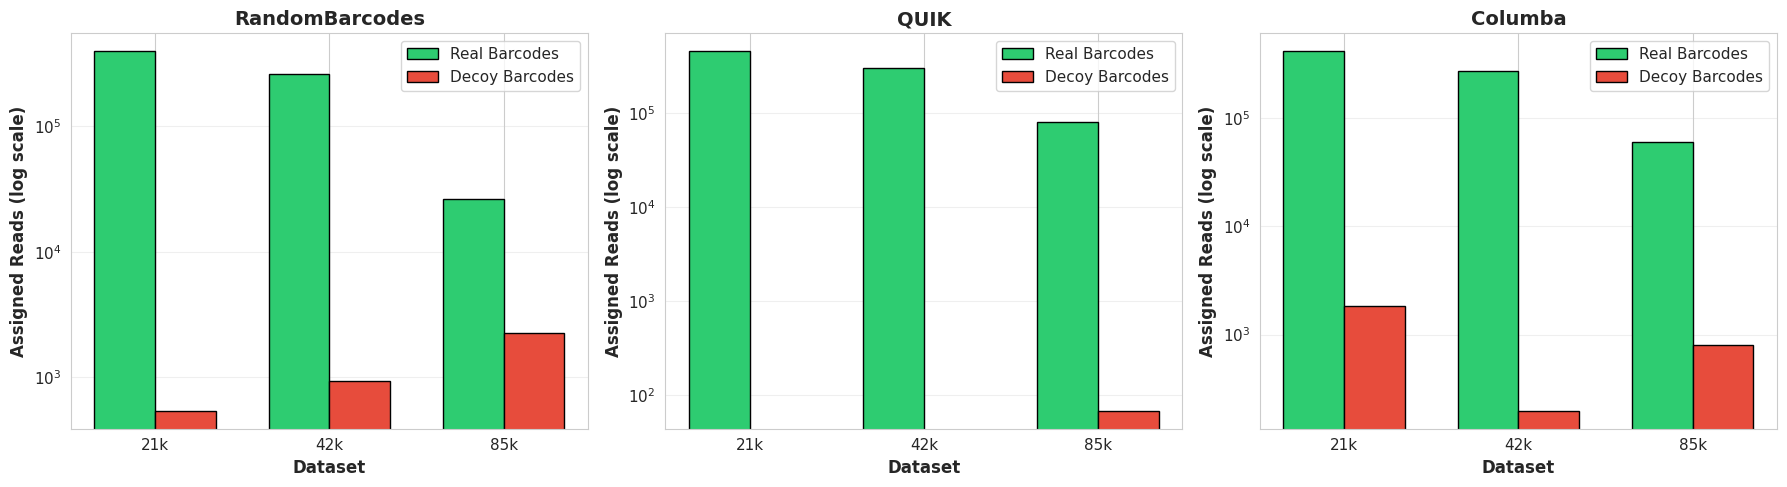


Figure saved: figures/real_vs_decoy_assignment.png


In [ ]:
# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, tool in enumerate(tools):
    ax = axes[idx]
    tool_data = df[df['Tool'] == tool].sort_values('Dataset')
    
    x = np.arange(len(datasets))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, tool_data['Assigned_Reads'], width, label='Real Barcodes', color='#2ecc71', edgecolor='black')
    bars2 = ax.bar(x + width/2, tool_data['Decoy_Assigned'], width, label='Decoy Barcodes', color='#e74c3c', edgecolor='black')
    
    ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
    ax.set_ylabel('Assigned Reads', fontsize=12, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_yscale('log')
    ax.set_ylabel('Assigned Reads (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/real_vs_decoy_assignment.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/real_vs_decoy_assignment.png")

## 4. Key Findings Summary

In [6]:
print("\n" + "="*60)
print(" "*15 + "KEY FINDINGS SUMMARY")
print("="*60 + "\n")

for tool in tools:
    tool_data = df[df['Tool'] == tool]
    print(f"\n{tool}:")
    print("-" * 40)
    
    for dataset in datasets:
        data = tool_data[tool_data['Dataset'] == dataset].iloc[0]
        print(f"\n  {dataset} dataset:")
        print(f"    Total reads: {data['Total_Reads']:,}")
        print(f"    Assigned reads (real): {data['Assigned_Reads']:,} ({data['Assignment_Rate']:.2f}%)")
        print(f"    Assigned reads (decoy): {data['Decoy_Assigned']:,} ({data['False_Positive_Rate']:.3f}%)")
        print(f"    Precision: {data['Precision']:.3f}%")

print("\n" + "="*60)
print("\nOverall Performance Ranking (by Precision):")
print("-" * 40)
avg_precision = df.groupby('Tool')['Precision'].mean().sort_values(ascending=False)
for rank, (tool, precision) in enumerate(avg_precision.items(), 1):
    print(f"{rank}. {tool}: {precision:.3f}%")

print("\n" + "="*60)


               KEY FINDINGS SUMMARY


RandomBarcodes:
----------------------------------------

  21k dataset:
    Total reads: 657,529
    Assigned reads (real): 397,108 (60.39%)
    Assigned reads (decoy): 542 (0.082%)
    Precision: 99.918%

  42k dataset:
    Total reads: 526,931
    Assigned reads (real): 263,985 (50.10%)
    Assigned reads (decoy): 933 (0.177%)
    Precision: 99.823%

  85k dataset:
    Total reads: 420,338
    Assigned reads (real): 26,174 (6.23%)
    Assigned reads (decoy): 2,260 (0.538%)
    Precision: 99.462%

QUIK:
----------------------------------------

  21k dataset:
    Total reads: 657,529
    Assigned reads (real): 450,460 (68.51%)
    Assigned reads (decoy): 0 (0.000%)
    Precision: 100.000%

  42k dataset:
    Total reads: 526,931
    Assigned reads (real): 301,062 (57.13%)
    Assigned reads (decoy): 0 (0.000%)
    Precision: 100.000%

  85k dataset:
    Total reads: 420,338
    Assigned reads (real): 79,381 (18.89%)
    Assigned reads (decoy): 6

## 5. Export Results

In [7]:
# Export results to CSV
output_file = '../notebooks/real_data_comparison_results.csv'
df.to_csv(output_file, index=False)
print(f"\nResults exported to: {output_file}")

# Create figures directory if it doesn't exist
import os
os.makedirs('../notebooks/figures', exist_ok=True)
print("\nAll figures saved to: notebooks/figures/")


Results exported to: ../notebooks/real_data_comparison_results.csv

All figures saved to: notebooks/figures/


## 6. Barcode Overlap Analysis

Analyze the overlap in specific barcodes called by each tool to understand which barcodes are consistently detected across tools vs. tool-specific calls.

In [10]:
def extract_barcodes_from_randombarcodes(fastq_file):
    """Extract called barcode sequences from RandomBarcodes FASTQ file.
    
    Format: @... 2:N:0:ATGGCGAT+GTTACGCA_calledidx_851_GAGGATCAAACACTGAACACCTACCCGCTCTGCTCG
    Returns: dict mapping barcode_sequence -> read_count
    """
    barcodes = {}
    with open(fastq_file, 'r') as f:
        for line in f:
            if line.startswith('@'):
                # Extract barcode from header
                # Format has _calledidx_ at the end of the line
                if '_calledidx_' in line:
                    # Split by _calledidx_ and take the part after it
                    parts = line.strip().split('_calledidx_')
                    if len(parts) >= 2:
                        # Get barcode sequence (after the index ID)
                        # Format: ID_BARCODE_SEQUENCE
                        barcode_part = parts[1]
                        # Extract barcode sequence (after the numeric ID)
                        if '_' in barcode_part:
                            barcode_seq = barcode_part.split('_', 1)[1]
                            barcodes[barcode_seq] = barcodes.get(barcode_seq, 0) + 1
    return barcodes

def extract_barcodes_from_quik(fastq_file):
    """Extract called barcode sequences from QUIK FASTQ file.
    
    Format: @M04784:814:000000000-GR2FH:1:1102:16333:1354_calledidx_12816_GAGCGTAGAGATCGTACAATAACCACGCCAGAACAC 1:N:0:ATGGCGAT+GTTACGCA
    Returns: dict mapping barcode_sequence -> read_count
    """
    barcodes = {}
    with open(fastq_file, 'r') as f:
        for line in f:
            if line.startswith('@'):
                # Extract barcode from header
                if '_calledidx_' in line:
                    # Split by space first to isolate the main identifier
                    main_part = line.strip().split()[0]
                    parts = main_part.split('_calledidx_')
                    if len(parts) >= 2:
                        # Get barcode sequence (after the index ID)
                        barcode_part = parts[1]
                        # Extract barcode sequence (after the numeric ID)
                        if '_' in barcode_part:
                            barcode_seq = barcode_part.split('_', 1)[1]
                            barcodes[barcode_seq] = barcodes.get(barcode_seq, 0) + 1
    return barcodes

def load_barcode_reference(barcode_file):
    """Load barcode reference sequences.
    
    Returns: list of barcode sequences (1-indexed, barcode_0 is line 0)
    """
    barcodes = []
    with open(barcode_file, 'r') as f:
        for line in f:
            barcodes.append(line.strip())
    return barcodes

def extract_barcodes_from_columba(sam_file, barcode_reference):
    """Extract called barcode sequences from Columba SAM file (forward-mapped only).

    Notes:
    - Uses SAM FLAG (2nd column) to filter alignments.
    - Only counts reads that are:
        * mapped (FLAG bit 4 not set)
        * forward (FLAG bit 16 not set)
        * primary (skips secondary 0x100 and supplementary 0x800 to avoid double counting)
    - Barcode ID is taken from RNAME (3rd column), expected format: barcode_<idx>

    Returns: dict mapping barcode_sequence -> read_count
    """
    FLAG_UNMAPPED = 0x4
    FLAG_REVERSE = 0x10
    FLAG_SECONDARY = 0x100
    FLAG_SUPPLEMENTARY = 0x800

    barcodes = {}
    with open(sam_file, 'r') as f:
        for line in f:
            if line.startswith('@'):
                continue  # Skip header lines

            fields = line.rstrip('\n').split('\t')
            if len(fields) < 3:
                continue

            # Parse FLAG
            try:
                flag = int(fields[1])
            except ValueError:
                continue

            # Filter to mapped, forward, primary alignments only
            if flag & FLAG_UNMAPPED:
                continue
            if flag & FLAG_REVERSE:
                continue
            if flag & (FLAG_SECONDARY | FLAG_SUPPLEMENTARY):
                continue

            rname = fields[2]  # Reference name (e.g., "barcode_7211")
            if not rname.startswith('barcode_'):
                continue

            # Extract barcode index
            try:
                barcode_idx = int(rname.split('_', 1)[1])
            except (ValueError, IndexError):
                continue

            # Map to actual barcode sequence (0-indexed in list)
            if 0 <= barcode_idx < len(barcode_reference):
                barcode_seq = barcode_reference[barcode_idx].upper()
                barcodes[barcode_seq] = barcodes.get(barcode_seq, 0) + 1

    return barcodes

print("Functions defined for extracting barcodes from tool outputs.")

Functions defined for extracting barcodes from tool outputs.


In [11]:
# Extract barcodes from each tool for all datasets
barcode_data = {}

# Define barcode reference files
barcode_files = {
    '21k': '/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/BCseq_01/bar_1in4_column_major.txt',
    '42k': '/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/BCseq_01/bar_1in2_column_major.txt',
    '85k': '/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/BCseq_01/bar_1in1_column_major.txt'
}

for dataset in datasets:
    print(f"\n{'='*60}")
    print(f"Processing {dataset} dataset...")
    print('='*60)
    
    # Load barcode reference
    barcode_ref = load_barcode_reference(barcode_files[dataset])
    print(f"Loaded {len(barcode_ref)} reference barcodes")
    
    # RandomBarcodes
    rb_file = results_dir / f'randombarcodes/{dataset}/RB_real_{dataset}/RB_real_{dataset}_R1_filtered.fastq'
    rb_barcodes = extract_barcodes_from_randombarcodes(rb_file)
    print(f"RandomBarcodes: {len(rb_barcodes)} unique barcodes called")
    
    # QUIK
    quik_file = results_dir / f'quik/{dataset}/QUIK_real_{dataset}/QUIK_real_{dataset}_R1_filtered.fastq'
    quik_barcodes = extract_barcodes_from_quik(quik_file)
    print(f"QUIK: {len(quik_barcodes)} unique barcodes called")
    
    # Columba
    columba_file = results_dir / f'columba/{dataset}_I77/Columba_real_{dataset}_I77/Columba_real_{dataset}_I77_alignment.sam'
    columba_barcodes = extract_barcodes_from_columba(columba_file, barcode_ref)
    print(f"Columba: {len(columba_barcodes)} unique barcodes called")
    
    # Store results
    barcode_data[dataset] = {
        'RandomBarcodes': rb_barcodes,
        'QUIK': quik_barcodes,
        'Columba': columba_barcodes,
        'reference': barcode_ref
    }
    
    # Calculate overlaps
    rb_set = set(rb_barcodes.keys())
    quik_set = set(quik_barcodes.keys())
    columba_set = set(columba_barcodes.keys())
    
    print(f"\nOverlap statistics:")
    print(f"  All 3 tools: {len(rb_set & quik_set & columba_set)} barcodes")
    print(f"  RB & QUIK: {len(rb_set & quik_set)} barcodes")
    print(f"  RB & Columba: {len(rb_set & columba_set)} barcodes")
    print(f"  QUIK & Columba: {len(quik_set & columba_set)} barcodes")
    print(f"  RB only: {len(rb_set - quik_set - columba_set)} barcodes")
    print(f"  QUIK only: {len(quik_set - rb_set - columba_set)} barcodes")
    print(f"  Columba only: {len(columba_set - rb_set - quik_set)} barcodes")


Processing 21k dataset...
Loaded 21476 reference barcodes
RandomBarcodes: 20294 unique barcodes called
QUIK: 20649 unique barcodes called
Columba: 20357 unique barcodes called

Overlap statistics:
  All 3 tools: 20258 barcodes
  RB & QUIK: 20292 barcodes
  RB & Columba: 20259 barcodes
  QUIK & Columba: 20352 barcodes
  RB only: 1 barcodes
  QUIK only: 263 barcodes
  Columba only: 4 barcodes

Processing 42k dataset...
Loaded 42653 reference barcodes
RandomBarcodes: 35077 unique barcodes called
QUIK: 36304 unique barcodes called
Columba: 35792 unique barcodes called

Overlap statistics:
  All 3 tools: 35008 barcodes
  RB & QUIK: 35067 barcodes
  RB & Columba: 35011 barcodes
  QUIK & Columba: 35613 barcodes
  RB only: 7 barcodes
  QUIK only: 632 barcodes
  Columba only: 176 barcodes

Processing 85k dataset...
Loaded 85305 reference barcodes
RandomBarcodes: 18303 unique barcodes called
QUIK: 39073 unique barcodes called
Columba: 43048 unique barcodes called

Overlap statistics:
  All 3 to

### 6.1 Venn Diagrams - Barcode Overlap Between Tools

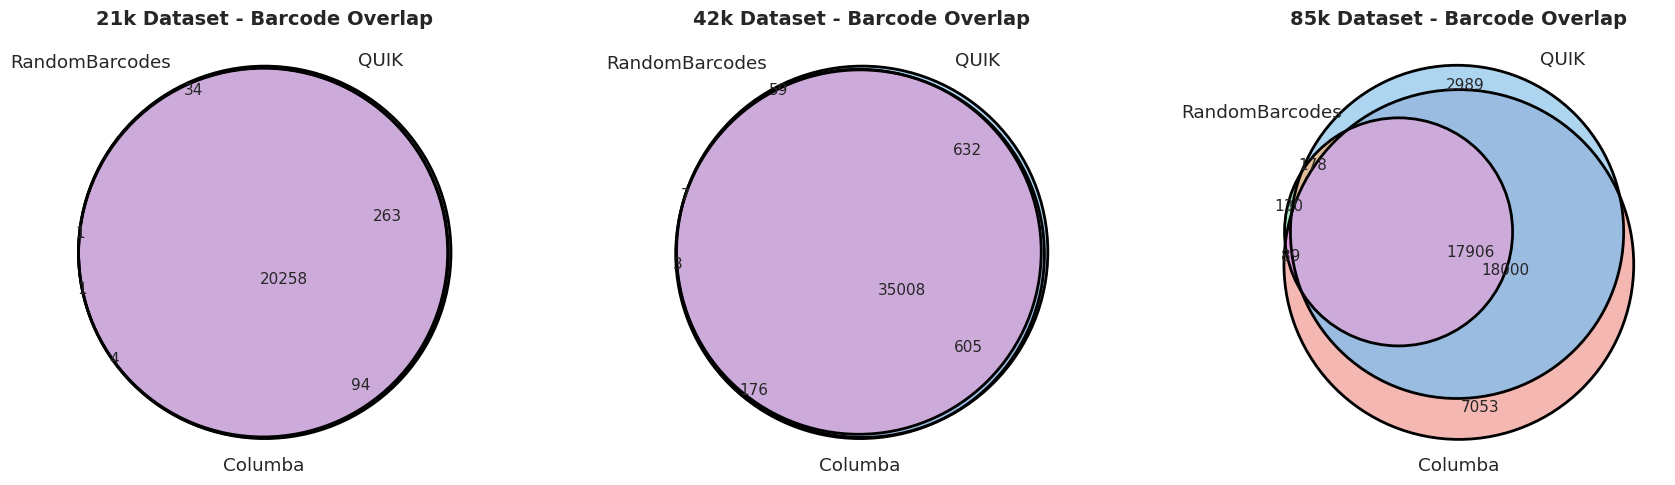


Figure saved: figures/barcode_overlap_venn.png


In [12]:
# Install matplotlib-venn if not already available
try:
    from matplotlib_venn import venn3, venn3_circles
except ImportError:
    import subprocess
    import sys
    print("Installing matplotlib-venn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib-venn", "-q"])
    from matplotlib_venn import venn3, venn3_circles

# Create Venn diagrams for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Get barcode sets
    rb_set = set(barcode_data[dataset]['RandomBarcodes'].keys())
    quik_set = set(barcode_data[dataset]['QUIK'].keys())
    columba_set = set(barcode_data[dataset]['Columba'].keys())
    
    # Create Venn diagram (without alpha parameter to venn3, we'll set it per patch)
    venn = venn3([rb_set, quik_set, columba_set], 
                 set_labels=('RandomBarcodes', 'QUIK', 'Columba'),
                 ax=ax)
    
    # Set consistent alpha for all patches (regions)
    # Only-RandomBarcodes region (100)
    if venn.get_patch_by_id('100'):
        venn.get_patch_by_id('100').set_color('#2ecc71')
        venn.get_patch_by_id('100').set_alpha(0.4)
    
    # Only-QUIK region (010)
    if venn.get_patch_by_id('010'):
        venn.get_patch_by_id('010').set_color('#3498db')
        venn.get_patch_by_id('010').set_alpha(0.4)
    
    # Only-Columba region (001)
    if venn.get_patch_by_id('001'):
        venn.get_patch_by_id('001').set_color('#e74c3c')
        venn.get_patch_by_id('001').set_alpha(0.4)
    
    # RB & QUIK overlap (110)
    if venn.get_patch_by_id('110'):
        venn.get_patch_by_id('110').set_alpha(0.4)
    
    # RB & Columba overlap (101)
    if venn.get_patch_by_id('101'):
        venn.get_patch_by_id('101').set_alpha(0.4)
    
    # QUIK & Columba overlap (011)
    if venn.get_patch_by_id('011'):
        venn.get_patch_by_id('011').set_alpha(0.4)
    
    # All 3 tools overlap (111)
    if venn.get_patch_by_id('111'):
        venn.get_patch_by_id('111').set_color('#9b59b6')
        venn.get_patch_by_id('111').set_alpha(0.5)
    
    # Add circle outlines (3 circles, one for each set)
    venn3_circles([rb_set, quik_set, columba_set], ax=ax, linewidth=2.0, linestyle='solid', color='black')
    
    ax.set_title(f'{dataset} Dataset - Barcode Overlap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/barcode_overlap_venn.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/barcode_overlap_venn.png")

### 6.2 Overlap Summary Table

In [13]:
# Create detailed overlap summary
overlap_summary = []

for dataset in datasets:
    rb_set = set(barcode_data[dataset]['RandomBarcodes'].keys())
    quik_set = set(barcode_data[dataset]['QUIK'].keys())
    columba_set = set(barcode_data[dataset]['Columba'].keys())
    
    all_three = rb_set & quik_set & columba_set
    rb_quik = (rb_set & quik_set) - columba_set
    rb_columba = (rb_set & columba_set) - quik_set
    quik_columba = (quik_set & columba_set) - rb_set
    rb_only = rb_set - quik_set - columba_set
    quik_only = quik_set - rb_set - columba_set
    columba_only = columba_set - rb_set - quik_set
    
    total_unique = len(rb_set | quik_set | columba_set)
    
    overlap_summary.append({
        'Dataset': dataset,
        'Total_Unique_Barcodes': total_unique,
        'All_3_Tools': len(all_three),
        'All_3_Tools_%': f"{len(all_three)/total_unique*100:.1f}%",
        'RB_&_QUIK_only': len(rb_quik),
        'RB_&_Columba_only': len(rb_columba),
        'QUIK_&_Columba_only': len(quik_columba),
        'RB_only': len(rb_only),
        'QUIK_only': len(quik_only),
        'Columba_only': len(columba_only),
        'RB_unique': len(rb_set),
        'QUIK_unique': len(quik_set),
        'Columba_unique': len(columba_set)
    })

overlap_df = pd.DataFrame(overlap_summary)
print("\n=== Barcode Overlap Summary ===" )
print(overlap_df.to_string(index=False))


=== Barcode Overlap Summary ===
Dataset  Total_Unique_Barcodes  All_3_Tools All_3_Tools_%  RB_&_QUIK_only  RB_&_Columba_only  QUIK_&_Columba_only  RB_only  QUIK_only  Columba_only  RB_unique  QUIK_unique  Columba_unique
    21k                  20655        20258         98.1%              34                  1                   94        1        263             4      20294        20649           20357
    42k                  36490        35008         95.9%              59                  3                  605        7        632           176      35077        36304           35792
    85k                  46345        17906         38.6%             178                 89                18000      130       2989          7053      18303        39073           43048


### 6.3 Overlap Heatmap - Jaccard Similarity

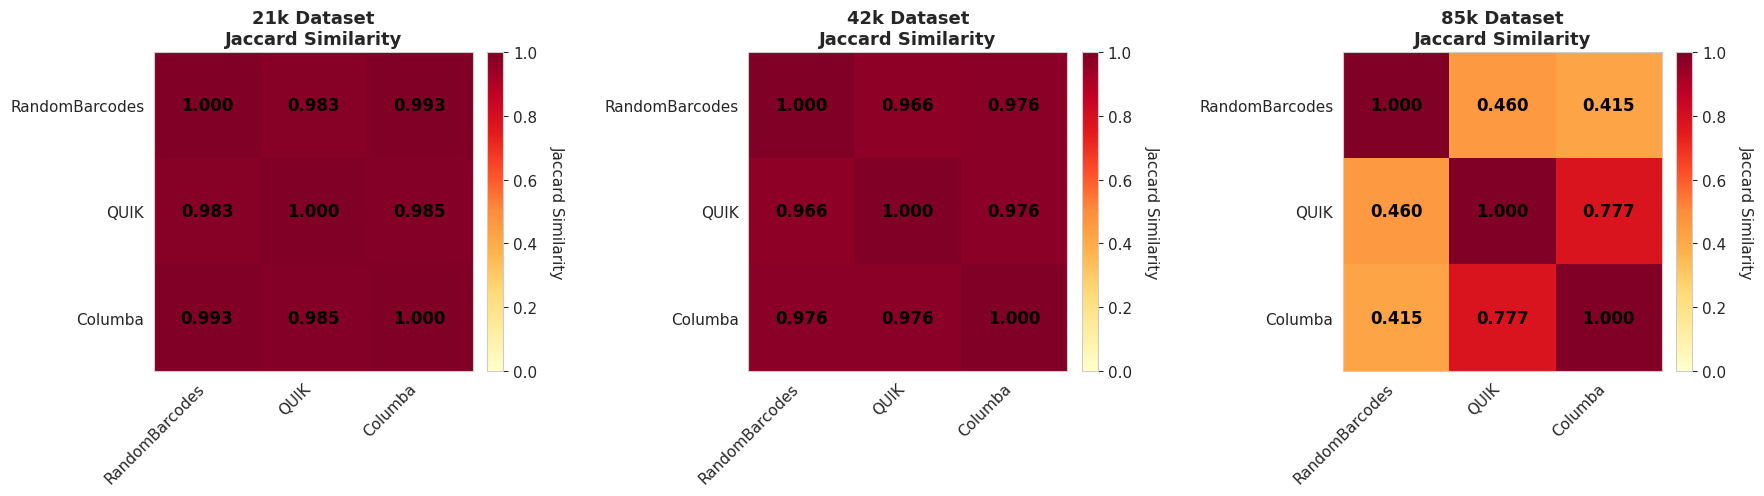


Figure saved: figures/barcode_overlap_jaccard.pdf

Jaccard Similarity: |A ∩ B| / |A ∪ B|
Values closer to 1 indicate higher overlap between tool outputs.


In [14]:
# Calculate Jaccard similarity between tools
def jaccard_similarity(set1, set2):
    """Calculate Jaccard similarity coefficient."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

# Create similarity matrices for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Get barcode sets
    rb_set = set(barcode_data[dataset]['RandomBarcodes'].keys())
    quik_set = set(barcode_data[dataset]['QUIK'].keys())
    columba_set = set(barcode_data[dataset]['Columba'].keys())
    
    # Calculate similarity matrix
    tools_list = ['RandomBarcodes', 'QUIK', 'Columba']
    sets = [rb_set, quik_set, columba_set]
    
    similarity_matrix = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            similarity_matrix[i, j] = jaccard_similarity(sets[i], sets[j])
    
    # Create heatmap
    im = ax.imshow(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    
    # Add text annotations
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f'{similarity_matrix[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=12, fontweight='bold')
    
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(tools_list, rotation=45, ha='right')
    ax.set_yticklabels(tools_list)
    ax.set_title(f'{dataset} Dataset\nJaccard Similarity', fontsize=13, fontweight='bold')
    
    # Remove grid lines (which make it look like 6x6)
    ax.grid(False)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Jaccard Similarity', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('../notebooks/figures/barcode_overlap_jaccard.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/barcode_overlap_jaccard.pdf")
print("\nJaccard Similarity: |A ∩ B| / |A ∪ B|")
print("Values closer to 1 indicate higher overlap between tool outputs.")

**Note on visualization**: The heatmaps show a **3×3 matrix** (one cell for each pair of tools). The visual appearance may have looked like 6×6 due to minor gridlines, but these have been removed. Each heatmap compares the three tools (RandomBarcodes, QUIK, Columba) using Jaccard similarity coefficients ranging from 0 (no overlap) to 1 (complete overlap).

### 6.4 Overlap Heatmap - Gini Coefficient of Overlapping Barcodes

Gini coefficient measures the inequality in read distribution among overlapping barcodes. 
- **0** = perfect equality (all overlapping barcodes have equal read counts)
- **1** = perfect inequality (one barcode dominates all reads)

Higher Gini values indicate that a few barcodes capture most reads, while lower values suggest more uniform coverage.

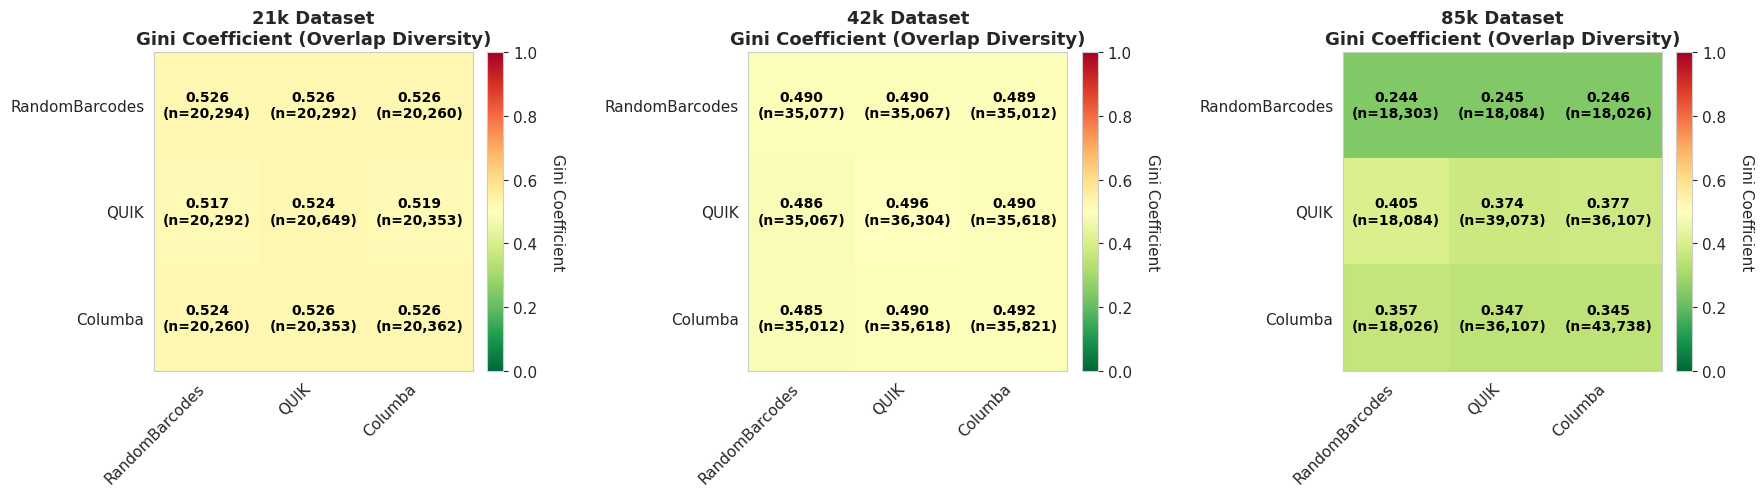


Figure saved: figures/barcode_overlap_gini.png

Gini Coefficient interpretation:
  - Low values (green): Uniform read distribution across overlapping barcodes
  - High values (red): Skewed distribution, few barcodes dominate reads
  - (n=X): Number of overlapping barcodes between the two tools


In [14]:
def calculate_gini_coefficient(read_counts):
    """Calculate Gini coefficient for a list of read counts.
    
    Gini coefficient measures inequality in distribution:
    - 0 = perfect equality (all values equal)
    - 1 = perfect inequality (one value has everything)
    """
    if len(read_counts) == 0:
        return np.nan
    
    # Sort values
    sorted_counts = np.sort(read_counts)
    n = len(sorted_counts)
    
    # Calculate Gini coefficient
    cumsum = np.cumsum(sorted_counts)
    gini = (2 * np.sum((np.arange(1, n+1)) * sorted_counts)) / (n * cumsum[-1]) - (n + 1) / n
    
    return gini

# Create Gini coefficient matrices for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Get barcode dictionaries (with read counts)
    rb_dict = barcode_data[dataset]['RandomBarcodes']
    quik_dict = barcode_data[dataset]['QUIK']
    columba_dict = barcode_data[dataset]['Columba']
    
    # Calculate Gini coefficient matrix
    tools_list = ['RandomBarcodes', 'QUIK', 'Columba']
    dicts = [rb_dict, quik_dict, columba_dict]
    
    gini_matrix = np.zeros((3, 3))
    overlap_counts = np.zeros((3, 3), dtype=int)  # Store overlap counts for annotation
    
    for i in range(3):
        for j in range(3):
            # Find overlapping barcodes
            common_barcodes = set(dicts[i].keys()) & set(dicts[j].keys())
            overlap_counts[i, j] = len(common_barcodes)
            
            if len(common_barcodes) > 0:
                # Get read counts for overlapping barcodes from tool i
                read_counts = [dicts[i][bc] for bc in common_barcodes]
                gini_matrix[i, j] = calculate_gini_coefficient(read_counts)
            else:
                gini_matrix[i, j] = np.nan
    
    # Create heatmap
    im = ax.imshow(gini_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
    
    # Add text annotations (Gini coefficient with overlap count below)
    for i in range(3):
        for j in range(3):
            if not np.isnan(gini_matrix[i, j]):
                text = ax.text(j, i, f'{gini_matrix[i, j]:.3f}\n(n={overlap_counts[i, j]:,})',
                              ha="center", va="center", color="black", fontsize=10, fontweight='bold')
            else:
                text = ax.text(j, i, 'N/A',
                              ha="center", va="center", color="gray", fontsize=10)
    
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(tools_list, rotation=45, ha='right')
    ax.set_yticklabels(tools_list)
    ax.set_title(f'{dataset} Dataset\nGini Coefficient (Overlap Diversity)', fontsize=13, fontweight='bold')
    
    # Remove grid lines
    ax.grid(False)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Gini Coefficient', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('../notebooks/figures/barcode_overlap_gini.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/barcode_overlap_gini.png")
print("\nGini Coefficient interpretation:")
print("  - Low values (green): Uniform read distribution across overlapping barcodes")
print("  - High values (red): Skewed distribution, few barcodes dominate reads")
print("  - (n=X): Number of overlapping barcodes between the two tools")

### 6.5 Barcode Coverage Analysis

Analyze how many of the reference barcodes were detected by each tool and their combinations.

In [15]:
# Analyze barcode coverage (what % of reference barcodes were detected)
coverage_data = []

for dataset in datasets:
    rb_set = set(barcode_data[dataset]['RandomBarcodes'].keys())
    quik_set = set(barcode_data[dataset]['QUIK'].keys())
    columba_set = set(barcode_data[dataset]['Columba'].keys())
    reference_set = set(barcode_data[dataset]['reference'])
    
    n_ref = len(reference_set)
    
    coverage_data.append({
        'Dataset': dataset,
        'Reference_Barcodes': n_ref,
        'RB_Detected': len(rb_set),
        'RB_Coverage_%': f"{len(rb_set)/n_ref*100:.1f}%",
        'QUIK_Detected': len(quik_set),
        'QUIK_Coverage_%': f"{len(quik_set)/n_ref*100:.1f}%",
        'Columba_Detected': len(columba_set),
        'Columba_Coverage_%': f"{len(columba_set)/n_ref*100:.1f}%",
        'Union_Detected': len(rb_set | quik_set | columba_set),
        'Union_Coverage_%': f"{len(rb_set | quik_set | columba_set)/n_ref*100:.1f}%"
    })

coverage_df = pd.DataFrame(coverage_data)
print("\n=== Barcode Coverage Analysis ===")
print("(What % of reference barcodes were detected by each tool)")
print(coverage_df.to_string(index=False))


=== Barcode Coverage Analysis ===
(What % of reference barcodes were detected by each tool)
Dataset  Reference_Barcodes  RB_Detected RB_Coverage_%  QUIK_Detected QUIK_Coverage_%  Columba_Detected Columba_Coverage_%  Union_Detected Union_Coverage_%
    21k               21476        20294         94.5%          20649           96.1%             20362              94.8%           20659            96.2%
    42k               42653        35077         82.2%          36304           85.1%             35821              84.0%           36514            85.6%
    85k               85305        18303         21.5%          39073           45.8%             43738              51.3%           46826            54.9%


In [17]:
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

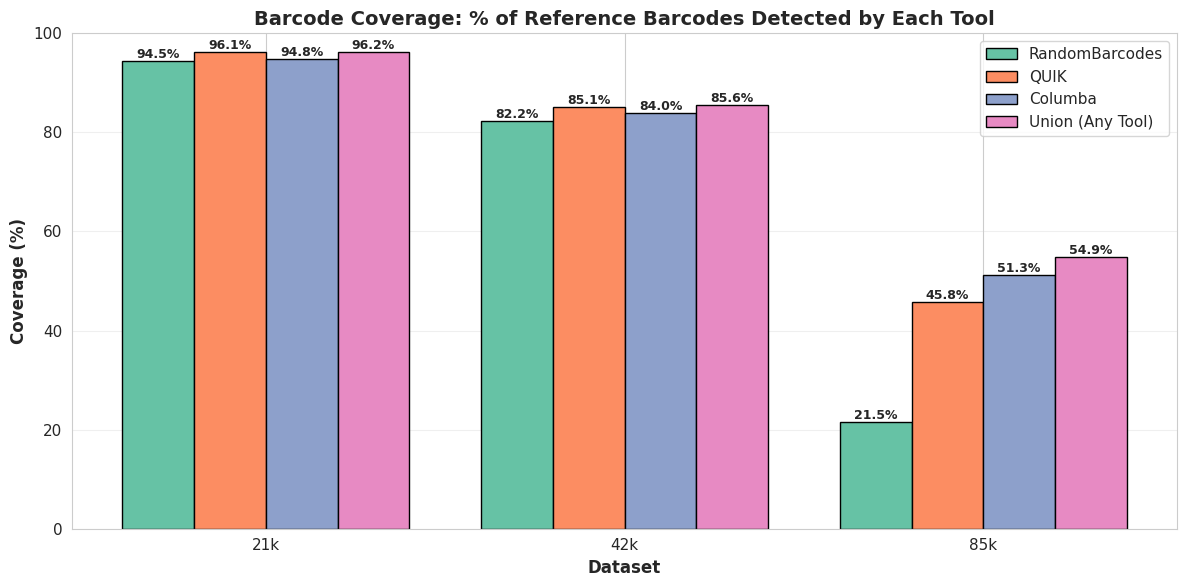


Figure saved: figures/barcode_coverage.pdf


In [20]:
# Visualize barcode coverage
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(datasets))
width = 0.2

# Extract numeric coverage values
for dataset in datasets:
    rb_set = set(barcode_data[dataset]['RandomBarcodes'].keys())
    quik_set = set(barcode_data[dataset]['QUIK'].keys())
    columba_set = set(barcode_data[dataset]['Columba'].keys())
    reference_set = set(barcode_data[dataset]['reference'])
    n_ref = len(reference_set)

# Plot bars
rb_coverage = [len(set(barcode_data[d]['RandomBarcodes'].keys()))/len(barcode_data[d]['reference'])*100 for d in datasets]
quik_coverage = [len(set(barcode_data[d]['QUIK'].keys()))/len(barcode_data[d]['reference'])*100 for d in datasets]
columba_coverage = [len(set(barcode_data[d]['Columba'].keys()))/len(barcode_data[d]['reference'])*100 for d in datasets]
union_coverage = [len(set(barcode_data[d]['RandomBarcodes'].keys()) | set(barcode_data[d]['QUIK'].keys()) | set(barcode_data[d]['Columba'].keys()))/len(barcode_data[d]['reference'])*100 for d in datasets]

bars1 = ax.bar(x - 1.5*width, rb_coverage, width, label='RandomBarcodes', color=palette[0], edgecolor='black')
bars2 = ax.bar(x - 0.5*width, quik_coverage, width, label='QUIK', color=palette[1], edgecolor='black')
bars3 = ax.bar(x + 0.5*width, columba_coverage, width, label='Columba', color=palette[2], edgecolor='black')
bars4 = ax.bar(x + 1.5*width, union_coverage, width, label='Union (Any Tool)', color=palette[3], edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Coverage (%)', fontsize=12, fontweight='bold')
ax.set_title('Barcode Coverage: % of Reference Barcodes Detected by Each Tool', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('../notebooks/figures/barcode_coverage.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/barcode_coverage.pdf")

### 6.5 Export Barcode Overlap Results

In [21]:
# Export overlap and coverage data
overlap_df.to_csv('../notebooks/barcode_overlap_summary.csv', index=False)
coverage_df.to_csv('../notebooks/barcode_coverage_summary.csv', index=False)

print("\nBarcode overlap analysis complete!")
print("Exported files:")
print("  - barcode_overlap_summary.csv")
print("  - barcode_coverage_summary.csv")
print("\nGenerated figures:")
print("  - figures/barcode_overlap_venn.png")
print("  - figures/barcode_overlap_jaccard.png")
print("  - figures/barcode_coverage.png")


Barcode overlap analysis complete!
Exported files:
  - barcode_overlap_summary.csv
  - barcode_coverage_summary.csv

Generated figures:
  - figures/barcode_overlap_venn.png
  - figures/barcode_overlap_jaccard.png
  - figures/barcode_coverage.png
